#<h1><center>Teste 2</center></h1>

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# <h2><center>EDO</center></h2>


In [96]:
alfa = 1
beta = 1
x0 = 0.01
t0 = 0

h = 0.1 # delta t
tau = 10 # T

T = np.arange(t0,tau,h)
N = int(tau / h)

sol = np.zeros(N)
sol[0] = x0
for i in np.arange(N-1):
    t = T[i]
    xi = sol[i]
    f_i = (alfa - beta * xi) * xi
    sol[i+1] = sol[i] + h*f_i


### Animação

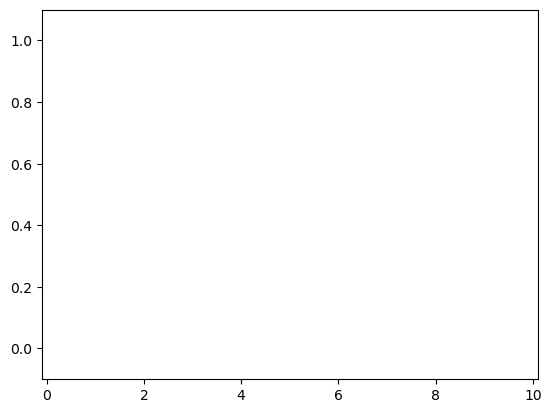

In [108]:
fig,ax = plt.subplots()
ax.set_xlim(-0.1,10.1)
ax.set_ylim(-0.1,1.1)

plot = ax.plot([],[])[0]

def animate_func(frame):
    t = 1 * frame
    plot.set_xdata(T[:t])
    plot.set_ydata(sol[:t])
    return plot
    
anim = animation.FuncAnimation(fig, animate_func, frames=int(len(T)), interval=50, blit=False)
HTML(anim.to_html5_video())

## <h2><center>EDO com parâmetros aleatórios</center></h2>

In [175]:
# parâmetros dos parâmetros
mu_a, var_a = 1,0.1
mu_b, var_b = 1,0.1
mu_x0 , var_x0 = 0.01,0.001


t0 = 0

h = 0.1 # delta t
tau = 10 # T

T = np.arange(t0,tau,h)
N = int(tau / h)

n_sims = 100
sims = np.zeros((n_sims,N))

for j in range(n_sims):
    
    alfa = np.random.normal(mu_a , var_a)
    beta = np.random.normal(mu_b , var_b)
    x0 = np.random.normal(mu_x0 , var_x0)

    sol = np.zeros(N) # array que guarda as solução em cada passo
    sol[0] = x0
    for i in np.arange(N-1):
        t = T[i]
        xi = sol[i]
        
        f_i = (alfa - beta * xi) * xi
        sol[i+1] = sol[i] + h*f_i
    
    sims[j] = sol


### Animação:

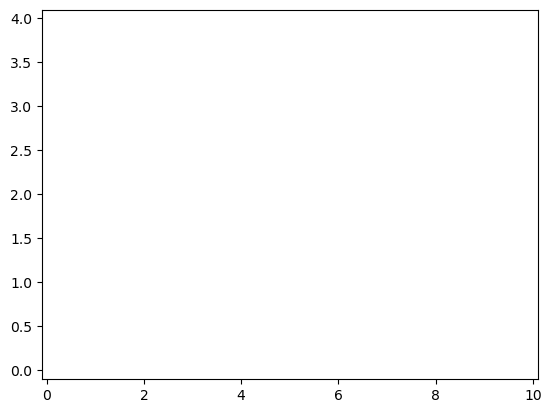

In [198]:
fig,ax = plt.subplots()
ax.set_xlim(-0.1,10.1)
ax.set_ylim(-0.1,4.1)

plots = [ax.plot([],[])[0] for _ in range(n_sims)]


def animate_func(frame):
    t = 1 * frame
    for i,plot in enumerate(plots):
        plot.set_xdata(T[:t])
        plot.set_ydata(sims[i,:t])
    return plots

anim = animation.FuncAnimation(fig, animate_func, frames=int(len(T)), interval=50, blit=False)
HTML(anim.to_html5_video())

## <h2><center>EDO com parâmetros estocásticos</center></h2>

In [255]:
# parâmetros 
a = 1.0
b = 1.0
sigma = 0.5
x0 = 0.01


t0 = 0

h = 0.1 # delta t
tau = 10 # T

T = np.arange(t0,tau,h)
N = int(tau / h)

n_sims = 100
sims = np.zeros((n_sims,N))

for j in range(n_sims):
    
    sol = np.zeros(N) # array que guarda as solução em cada passo
    sol[0] = x0
    for i in np.arange(N-1):
        Wt = np.random.normal(0,t)
        At = a + sigma * np.sin(Wt)
        t = T[i]
        xi = sol[i]
        
        f_i = (At - b * xi) * xi
        sol[i+1] = sol[i] + h*f_i
    
    sims[j] = sol


### Animação

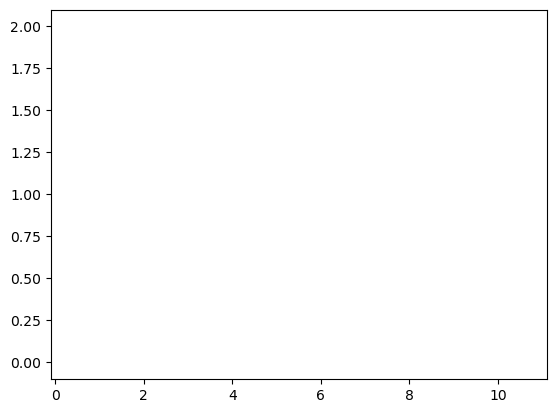

In [258]:
fig,ax = plt.subplots()
ax.set_xlim(-0.1,11.1)
ax.set_ylim(-0.1,2.1)

plots = [ax.plot([],[])[0] for _ in range(n_sims)]


def animate_func(frame):
    t = 1 * frame
    for i,plot in enumerate(plots):
        plot.set_xdata(T[:t])
        plot.set_ydata(sims[i,:t])
    return plots

anim = animation.FuncAnimation(fig, animate_func, frames=int(len(T)), interval=50, blit=False)
HTML(anim.to_html5_video())

## <h2><center>EDE</center></h2>

In [270]:
# parâmetros 
alfa = 1.0
beta = 1.0
sigma = 1
x0 = 0.01


t0 = 0

h = 0.1 # delta t
tau = 10 # T

T = np.arange(t0,tau,h)
N = int(tau / h)

n_sims = 100
sims = np.zeros((n_sims,N))

for j in range(n_sims):
    
    sol = np.zeros(N) # array que guarda as solução em cada passo
    sol[0] = x0
    for i in np.arange(N-1):
        t = T[i]
        xi = sol[i]
        delta_W = np.random.normal(0,h)
        
        
        f_i = ((alfa - beta * xi) * xi) + (sigma * xi * (delta_W))
        sol[i+1] = sol[i] + h*f_i
    
    sims[j] = sol


### Animação

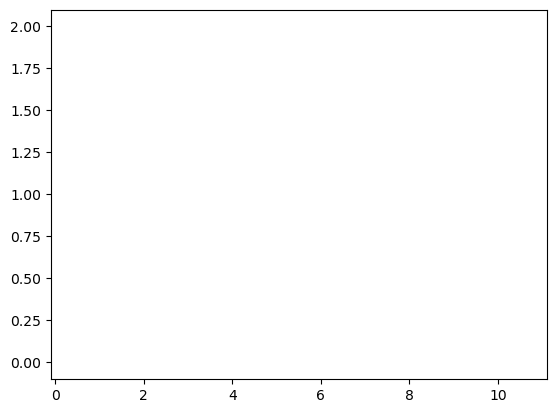

In [273]:
fig,ax = plt.subplots()
ax.set_xlim(-0.1,11.1)
ax.set_ylim(-0.1,2.1)

plots = [ax.plot([],[])[0] for _ in range(n_sims)]


def animate_func(frame):
    t = 1 * frame
    for i,plot in enumerate(plots):
        plot.set_xdata(T[:t])
        plot.set_ydata(sims[i,:t])
    return plots

anim = animation.FuncAnimation(fig, animate_func, frames=int(len(T)), interval=100, blit=False)
HTML(anim.to_html5_video())